In [5]:
title = "# Probabilities: Exercises"
# Print title and setup TeX defs for both KaTeX and MathJax
#import bayesian_stats_course_tools
#bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)

import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style
import matplotlib.ticker as mtick
#matplotlib.style.use("bayesian_stats_course_tools.light")

## Overview

Both exercises below are classic probability puzzles that are notorious for being unintuitive at first glance. For each one, you will:

1. Work out the probability **analytically**, using the definition of conditional probability and/or Bayes' theorem.
2. Check your answer with a **Monte-Carlo simulation**.

Getting the same answer from both directions is a good way to build confidence that you understand *why* the result holds, not just that you can reproduce a formula.

---
## Exercise 0: Warm-up — dice, sets, and Bayes' theorem

Before the two main exercises, a few short questions to refresh the concepts from the lecture: sample spaces, independence, and Bayes' theorem. These are quick — a couple of lines of code or algebra each.

1. Two fair six-sided dice are rolled. Enumerate the sample space $\Omega$ of the 36 equally-likely $(d_1, d_2)$ outcomes (e.g. with `itertools.product`), and use it to compute $P(\text{sum} = 7)$.
2. Let $A$ be "the sum is 7" and $B$ be "at least one die shows a 4". Are $A$ and $B$ independent? Check using $P(A \mid B) \overset{?}{=} P(A)$.
3. A rare disease affects 0.1% of the population. A test for it is 99% accurate on people who have it, and gives a false positive 2% of the time on people who don't. Using Bayes' theorem, what is $P(\text{disease} \mid \text{positive test})$?

> **Hint.** For question 3: $P(D \mid {+}) = \dfrac{P(+ \mid D)P(D)}{P(+ \mid D)P(D) + P(+ \mid D^c)P(D^c)}$ — the denominator is the law of total probability applied to $\{D, D^c\}$. The answer is smaller than most people expect; that's the point.


In [6]:
# Your code here: work through questions 1-3 above


---
## Exercise 1: The birthday problem

**Question.** What is the probability that at least two people in this room share a birthday?

More precisely: let $B_n$ be the event that at least two people out of $n$ share a birthday. Find $P(B_n)$.

**Assumptions:**
- Birthdays are independent between people.
- Every day of the year is equally likely to be someone's birthday.
- The year has 365 days (ignore leap years).

### Task

1. It is easier to work with the complementary event $B_n^c$ (no two people share a birthday). Write $P(B_n)$ in terms of $P(B_n^c)$.
2. Introduce the birthday $d_i$ of person $i$, and use independence to write $P(B_n^c)$ as a product of terms, one per person, that each ask "what is the probability this person's birthday differs from everyone before them?"
3. Simplify your product to a closed-form expression for $P(B_n^c)$, and hence for $P(B_n)$.
4. Evaluate $P(B_n)$ for $n = 17$ and $n = 23$. Which of these two group sizes gives roughly even odds?
5. Make a plot of $P(B_n)$ as a function of $n$, for $n$ from 1 to 60. At what $n$ does the room "feel" like a coin flip?

> **Hint.** For step 3, `math.factorial` will overflow or lose precision once $n$ gets large. Consider computing the product directly with `numpy` (e.g. via `np.prod` or `np.cumprod`), or working in log-space with `scipy.special.gammaln`, instead of forming $365!$ explicitly.

> **Bonus.** How does the answer change on a planet where the year has a different number of days? Turn your expression for $P(B_n)$ into a function of both $n$ and the number of days in the year, and see how the "50% group size" scales.

#### Your analytic derivation

*(Write your derivation of $P(B_n)$ here, e.g. using LaTeX in this markdown cell.)*

# Your code here: implement Pr(B_n) and evaluate it for n = 17 and n = 23

1. $P(B_n) = 1 - P(B_n^c)$

2. $P(B_n) = 1 - \frac{1}{365^n} \cdot \frac{365!}{(365-n)!}$

3. $P(B_n^c) = 1 - \frac{365}{365} \cdot \frac{364}{365} \cdot \frac{363}{365} \dotsm \frac{365-n}{365}$

4. $P(B_n^c) = 1 - \frac{\text{range from 365-n to 365 including 365]}}{n \times 365}$

In [7]:
# Your code here: plot Pr(B_n) as a function of n

# element-wise calculation of factorial series, because it breaks down otherwise
def P_BirthDay(x: int, n: int):
    upper = np.arange(x-n+1, x+1)
    #print(upper)
    days = np.full((1,np.size(upper)), x)
    #print(days)
    ratio = upper/days
    #print(ratio)
    factorial = np.prod(ratio)
    return factorial
    
#test calls
#p = P_BirthDay(365, 30)
#print(p)

# Probability of non-redundant birthdays
def same_birthday(n: int, days: int):
    pBD = P_BirthDay(days, n)
    return 1 - pBD

print(f"For N = 17 People, the chance of people sharing a birthday is: {same_birthday(17, 365):.4f}")
print(f'For N = 24 People, the chance of people sharing a birthday is: {same_birthday(24, 365):.4f}')





For N = 17 People, the chance of people sharing a birthday is: 0.3150
For N = 24 People, the chance of people sharing a birthday is: 0.5383


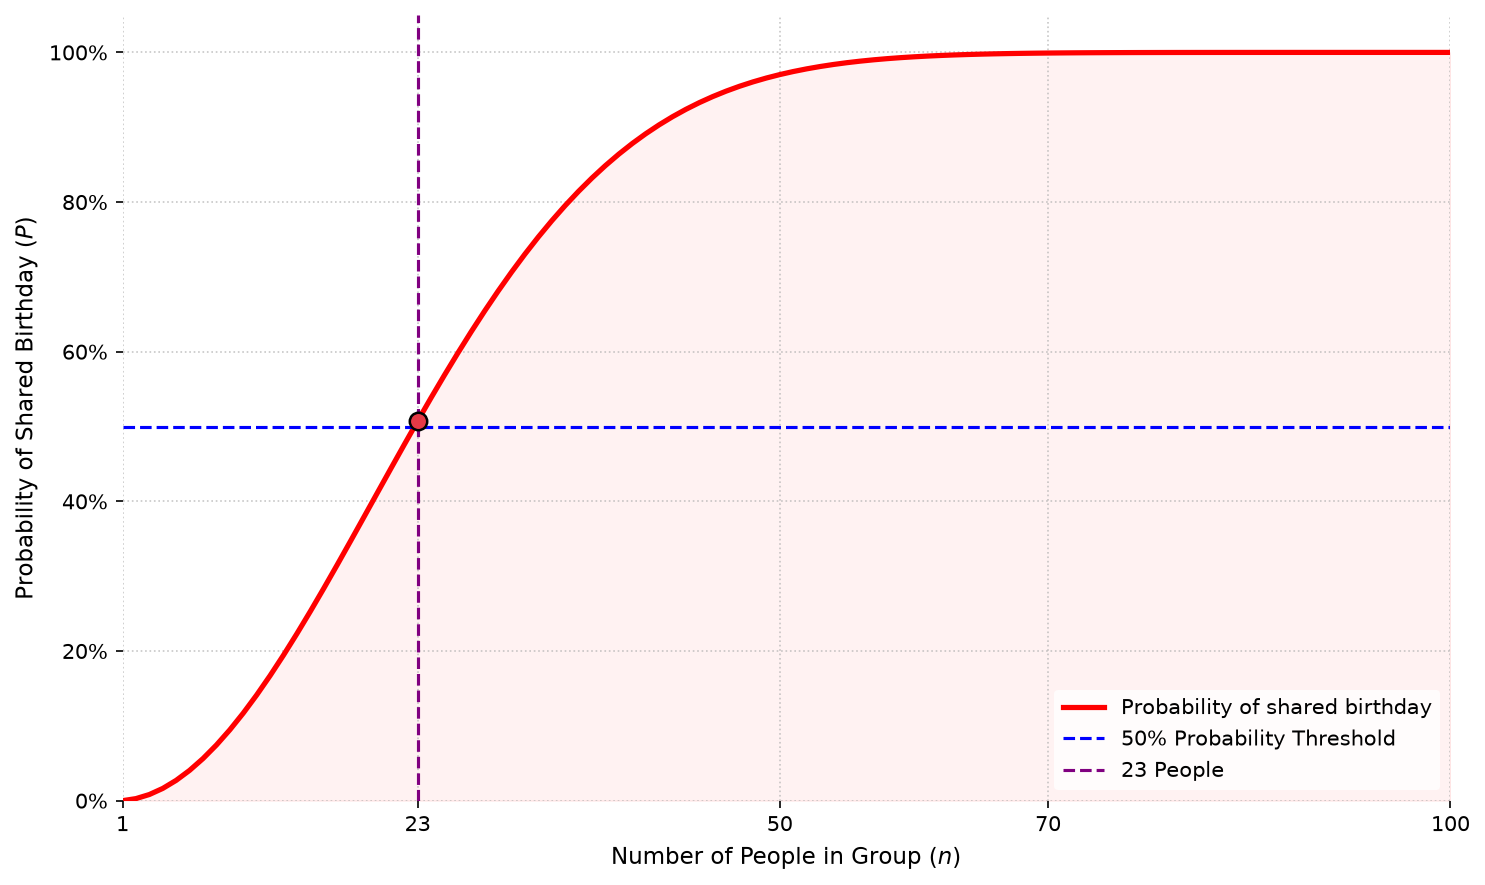

In [8]:
BD_Prob = [same_birthday(i, 365) for i in range(1,101)]
n_People = np.linspace(1,100, num=100)


# figure
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)


ax.plot(n_People, BD_Prob, color="red", linestyle="-", linewidth=2.5, label="Probability of shared birthday")
ax.fill_between(n_People, BD_Prob, color="red", alpha=0.05)

# Reference Lines (50% Probability)
ax.axhline(y=0.5, color="Blue", linestyle="--", linewidth=1.5, label="50% Probability Threshold")
n_50 = 23
p_50 = same_birthday(n_50, 365)
ax.axvline(x=23, color="Purple", linestyle="--", linewidth=1.5, label="23 People")
ax.scatter([n_50],[p_50],color="#E63946",s=70, zorder=5, edgecolor="black", linewidth=1.2)

ax.set_xlabel("Number of People in Group ($n$)", fontsize=11, labelpad=5)
ax.set_ylabel("Probability of Shared Birthday ($P$)", fontsize=11, labelpad=5)

ax.set_xlim(1, 100)
ax.set_ylim(0, 1.05)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) # with help from AI
ax.set_xticks([1, 23, 50, 70, 100])

ax.grid(visible=True, linestyle=":", linewidth=0.8, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.legend(loc="lower right", facecolor="white", edgecolor="none")

plt.tight_layout()
plt.show()

---
## Exercise 2: The Monty Hall problem

**Setup.** In a game show, a contestant is presented with three doors. Behind one door is a car, and behind the other two are goats. The goal is to win the car.

The game proceeds as follows:
1. The contestant chooses a door, which stays closed for now.
2. The host, who knows where the car is, opens one of the *other two* doors, always revealing a goat.
3. The contestant may now **stick** with their original door, or **switch** to the remaining closed door.

Let $M$ denote this hypothesis — the rules of the game exactly as just described (in particular: the car is placed uniformly at random behind one of the three doors, and the host, who knows where it is, always opens one of the remaining doors to reveal a goat). We'll write $M$ explicitly in the probabilities below, as a reminder that the answer follows from these specific rules of the game, not from the numbers "3 doors" alone.

**Question.** What is the best strategy? Concretely, suppose the contestant first chooses door 1 and the host opens door 3 (revealing a goat). What is $P(C_1 \mid H_3, M)$, the probability of winning by sticking, versus $P(C_2 \mid H_3, M)$, the probability of winning by switching?

### Task

You are free to tackle these two parts in either order — each is a useful check on the other.

**A. Simulate the game.**
1. Write a function that plays one round: randomly place the car, have the contestant pick a door, have the host open a door with a goat behind it (excluding the contestant's door and the car's door), and record whether *sticking* or *switching* would have won.
2. Repeat for many rounds (e.g. $10^5$) and estimate $P(\text{win} \mid \text{stick}, M)$ and $P(\text{win} \mid \text{switch}, M)$ from the simulated frequencies.

**B. Derive it analytically.**
1. Write out $P(C_1 \mid H_3, M)$ using Bayes' theorem:
$$P(C_1 \mid H_3, M) = \frac{P(H_3 \mid C_1, M)\,P(C_1 \mid M)}{P(H_3 \mid M)}$$
2. Work out each ingredient: the prior $P(C_i \mid M)$ for each door, and the likelihood $P(H_3 \mid C_i, M)$ for each door (i.e. how likely is the host to open door 3, given where the car actually is, under the rules $M$?).
3. Expand the denominator $P(H_3 \mid M)$ by summing over the three possible car locations, and put everything together.
4. Compare $P(C_1 \mid H_3, M)$ and $P(C_2 \mid H_3, M)$ to your simulated estimates from part A.

> **Hint.** The denominator $P(H_3 \mid M)$ is the same for both $P(C_1\mid H_3, M)$ and $P(C_2\mid H_3, M)$. If you only care about *which* strategy is better, you can sidestep computing it entirely by looking at the posterior odds $P(C_2 \mid H_3, M) / P(C_1 \mid H_3, M)$ instead.

> **Bonus.** How do the winning probabilities change if there are $N > 3$ doors, with the host still opening $N - 2$ goat-doors one at a time before offering the switch? (This changes the rules to a new hypothesis $M_N$.)

In [ ]:
# Your code here: simulate the Monty Hall game and estimate
# P(win | stick) and P(win | switch)


#### Your analytic derivation

*(Write your derivation of $P(C_1 \mid H_3, M)$ and $P(C_2 \mid H_3, M)$ here.)*